In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
import pandas as pd
df = pd.read_excel("/content/drive/MyDrive/Dollar_Rial_Price.xlsx")
df

,Year,Price
0,2011,15550
1,2012,32400
2,2013,30070
3,2014,35010
4,2015,33870
5,2016,39480
6,2017,42880
7,2018,108000
8,2019,129500
9,2020,257010


In [72]:
from matplotlib import pyplot as plt

Text(0.5, 1.0, 'Trend of Dollar to Rial Exchange Rate Over the Years')

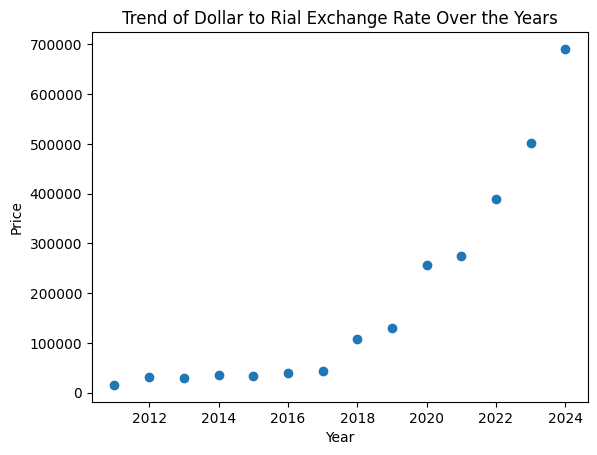

In [73]:
plt.scatter(df['Year'] , df['Price'])
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Trend of Dollar to Rial Exchange Rate Over the Years')

In [74]:
import numpy as np
X = np.array(df["Year"]).reshape(-1, 1)
Y = np.array(df["Price"])

In [75]:
X

array([[2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019],
       [2020],
       [2021],
       [2022],
       [2023],
       [2024]])

In [76]:
Y

array([ 15550,  32400,  30070,  35010,  33870,  39480,  42880, 108000,
       129500, 257010, 273880, 389000, 500950, 690770])

# **Random Forest Regressor**

In [77]:
#train the Random Forest model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, Y)


RandomForestRegressor(random_state=42)

In [78]:
future_years = np.arange(2025, 2031).reshape(-1, 1)
predicted_prices = model.predict(future_years)

In [79]:
predicted_prices

array([612194.5, 612194.5, 612194.5, 612194.5, 612194.5, 612194.5])

In [80]:
# Combine actual and predicted data into one DataFrame
all_years = np.concatenate((df["Year"], future_years.flatten()))
all_prices = np.concatenate((df["Price"], predicted_prices))

final_df = pd.DataFrame({
    "Year": all_years,
    "Price": all_prices
})

final_df

,Year,Price
0,2011,15550.0
1,2012,32400.0
2,2013,30070.0
3,2014,35010.0
4,2015,33870.0
5,2016,39480.0
6,2017,42880.0
7,2018,108000.0
8,2019,129500.0
9,2020,257010.0


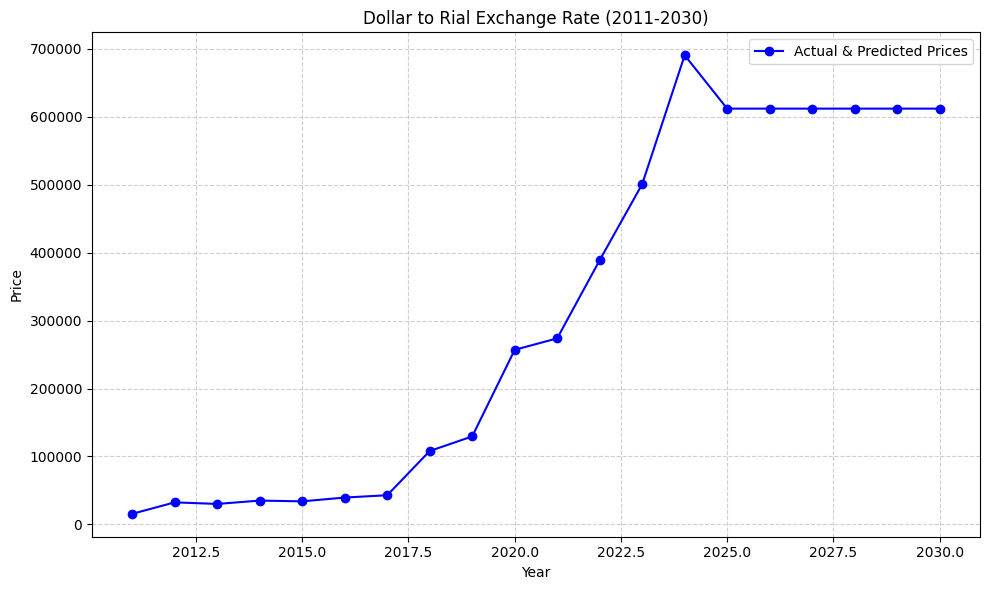

In [81]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(final_df["Year"], final_df["Price"], marker='o', linestyle='-', color='b', label="Actual & Predicted Prices")

# Add labels, title, and legend
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Dollar to Rial Exchange Rate (2011-2030)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()